# Pour le troisième pipeline, j’ai utilisé un autre type de modèle : un modèle de deep learning, le LSTM. J’ai donc adapté le prétraitement pour ce modèle, puisqu’il prend en considération l’ordre des mots, la ponctuation et les stopwords. Pour la vectorisation des reviews, j’ai utilisé l’embedding de Keras.

In [1]:
import pandas as pd
import regex as re
from collections import Counter
import numpy as np

## Data Loading

In [2]:
raw = pd.read_csv("../IMDB Dataset.csv")
raw = raw.drop_duplicates(subset='review', keep='first')

In [3]:
raw

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
raw[raw['review'].str.contains(r'@\w+', regex=True)].iloc[4,0]

"I have noticed that people have asked if anyone has this show. I have all 26 episodes that aired in the U.S. and will be willing to share these with anyone interested. All I require is that you supply the VHS tapes or Blank DVD's I have them on both formats and pay for shipping. My email is creator67@pipinternet.net, just send me an email and your request and I will notify you and we can make the arrangements. The quality is very good and they are very enjoyable to watch especially if you have not been able to see them since they aired in the 60's. It was one of my favorite shows as a child and hold a very special place in my heart because it brings back a lot of memories of my childhood as well as other shows like Ultraman and Astroboy.<br /><br />Peter"

# Prétraitement

On va faire un traitement similair au première, mais plus adapté au RNN.

Aprés l'exploration j'ai pas trouvé des user tags (@...) mais j'ai trouvé pas mal des emails, qui sont des données personnels, donc on les enlève.

In [5]:
raw[raw['review'].str.contains(r'\b[\w\.-]+@[\w\.-]+\.\w+\b')]

,review,sentiment
1281,I like many others saw this as a child and I l...,positive
3568,I have noticed that people have asked if anyon...,positive
5068,Brilliant adaptation of the largely interior m...,positive
8176,I could never remember the name of this show. ...,positive
8474,I'm like the rest of the fans who love this co...,positive
9510,I cant believe how many excellent actors can b...,positive
9978,I really can't say too much more about the plo...,positive
12166,Robert Jordan is a television star. Robert Jor...,positive
13471,This movie was everything but boring. It deals...,positive
13741,I LOVE this movie. and Disney channel is ridic...,positive


In [6]:
cleaning = raw.copy()

In [7]:
cleaning["review"] = cleaning["review"].apply(lambda x: re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' ', x))

In [8]:
cleaning[cleaning['review'].str.contains(r'\b[\w\.-]+@[\w\.-]+\.\w+\b')]

,review,sentiment


HTML tags

In [9]:
cleaning["review"] = cleaning["review"].apply(lambda x: re.sub(r"<.*?>", "", x))
cleaning["review"][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.I would say the main appeal of the show is due to the fact that it goes where other shows wo

lower case

In [10]:
cleaning["review"] = cleaning["review"].apply(lambda x: x.lower())
cleaning["review"][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wo

Expand contractions

In [11]:
import contractions
cleaning["review"] = cleaning["review"].apply(lambda x: contractions.fix(x))
cleaning["review"][0]

'one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. them city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other show

Lemmatization using Spacy

In [12]:
import spacy
nlp = spacy.load("en_core_web_sm")

cleaning["review"] = cleaning["review"].apply(lambda x: " ".join(token.lemma_ for token in nlp(x)))
cleaning["review"][0]

'one of the other reviewer have mention that after watch just 1 oz episode you will be hook . they be right , as this be exactly what happen with me.the first thing that strike I about oz be its brutality and unflinche scene of violence , which set in right from the word go . trust I , this be not a show for the faint hearted or timid . this show pull no punch with regard to drug , sex or violence . its be hardcore , in the classic use of the word.it be call oz as that be the nickname give to the oswald maximum security state penitentary . it focus mainly on emerald city , an experimental section of the prison where all the cell have glass front and face inward , so privacy be not high on the agenda . they city be home to many .. aryan , muslim , gangsta , latinos , christians , italian , irish and more .... so scuffle , death stare , dodgy dealing and shady agreement be never far away.i would say the main appeal of the show be due to the fact that it go where other show would not dare

In [13]:
cleaning["label"] = cleaning["sentiment"] == "positive"

In [14]:
cleaned = cleaning[["review", "label"]].copy()
cleaned

,review,label
0,one of the other reviewer have mention that af...,True
1,a wonderful little production . the filming te...,True
2,I think this be a wonderful way to spend time ...,True
3,basically there be a family where a little boy...,False
4,"petter mattei 's "" love in the time of money ""...",True
...,...,...
49995,I think this movie do a down right good job . ...,True
49996,"bad plot , bad dialogue , bad acting , idiotic...",False
49997,I be a catholic teach in parochial elementary ...,False
49998,I be go to have to disagree with the previous ...,False


On pass à la tokenization. <br>
Mais d'abord on doit savoir size de vocabulaire à appliquer sur tokenizer. On calcul le nombres des mots unique dans notre corpus et le Vocabulaire sera 95%.

In [15]:
all_words = " ".join(cleaned['review']).split()
unique_words = set(all_words)

print("Total tokens:", len(all_words))
print("Unique words:", len(unique_words))

Total tokens: 13149472
Unique words: 167864


In [16]:
counter = Counter(all_words)
word_freqs = np.array(sorted(counter.values(), reverse=True))
coverage = np.cumsum(word_freqs) / np.sum(word_freqs)

# Find vocab size covering 95%
vocab_95 = np.searchsorted(coverage, 0.95)
print("Words needed to cover 95% of dataset:", vocab_95)


Words needed to cover 95% of dataset: 7517


La taille de vocabulaire necessaire pour couvrir 95% des mots dans la dataset est 7517, mais on l'arrondi à 10k

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>") # Pour les mots qui ne sont pas de top 10k dans le vocabulaire, ils seront remplacé par OOV, ce qui aide le model de savoire qu'il y avait un mot là.
tokenizer.fit_on_texts(cleaned['review'])

word_index = tokenizer.word_index
print(f"Vocabulary size: {len(word_index)}")


Vocabulary size: 94102


In [18]:
sequences = tokenizer.texts_to_sequences(cleaned['review'])
print(sequences[:2])

[[28, 6, 2, 76, 1135, 14, 412, 12, 106, 61, 43, 298, 2784, 261, 23, 63, 3, 1796, 26, 3, 187, 17, 11, 3, 603, 50, 184, 19, 1770, 2, 90, 98, 12, 1197, 8, 46, 2784, 3, 100, 4602, 4, 1, 77, 6, 555, 70, 189, 10, 187, 39, 2, 356, 59, 1412, 8, 11, 3, 13, 5, 75, 18, 2, 5134, 2241, 42, 9564, 11, 75, 636, 65, 1740, 19, 1128, 7, 659, 373, 42, 555, 100, 3, 3337, 10, 2, 313, 137, 6, 2, 356, 9, 3, 229, 2784, 17, 12, 3, 2, 6832, 92, 7, 2, 1, 5845, 2302, 666, 1, 9, 646, 1335, 24, 1, 491, 35, 4034, 1959, 6, 2, 1088, 117, 30, 2, 1942, 14, 1829, 902, 4, 283, 1, 38, 1, 3, 13, 255, 24, 2, 3853, 26, 491, 3, 338, 7, 112, 1, 3779, 1, 1, 1, 963, 2221, 4, 58, 38, 1, 293, 3959, 6316, 8967, 4, 7191, 6943, 3, 116, 191, 238, 8, 52, 83, 2, 275, 969, 6, 2, 75, 3, 658, 7, 2, 177, 12, 9, 59, 117, 76, 75, 52, 13, 1887, 474, 179, 340, 1426, 18, 2264, 249, 474, 1167, 474, 778, 2784, 20, 13, 774, 182, 2, 90, 261, 8, 122, 29, 1197, 8, 17, 38, 1442, 9, 3, 2059, 8, 85, 13, 83, 8, 3, 1479, 18, 9, 21, 17, 8, 61, 58, 8, 732, 5, 

In [19]:
seq_lengths = [len(seq) for seq in sequences]

print(f"Minimum length: {np.min(seq_lengths)}")
print(f"Maximum length: {np.max(seq_lengths)}")
print(f"Mean length: {np.mean(seq_lengths):.2f}")
print(f"Median length: {np.median(seq_lengths)}")

Minimum length: 6
Maximum length: 2499
Mean length: 236.50
Median length: 177.0


In [20]:
MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f"Chosen MAX_LEN: {MAX_LEN}")


Chosen MAX_LEN: 604


In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
MAX_LEN = 200

X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
print(X.shape)

(49582, 200)


In [22]:
int(cleaned['label'][0])

1

In [23]:
y = cleaned['label'].astype(int).values

In [24]:
y

array([1, 1, 1, ..., 0, 0, 0], shape=(49582,))

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model Training

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

VOCAB_SIZE = 10000  # same as tokenizer
EMBEDDING_DIM = 100  # word embedding size

model = Sequential()
model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
model.add(LSTM(128, return_sequences=False))  # 128 units
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # binary classification

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 72s 125ms/step - accuracy: 0.5345 - loss: 0.6902 - val_accuracy: 0.6418 - val_loss: 0.6299
Epoch 2/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - accuracy: 0.6451 - loss: 0.6194 - val_accuracy: 0.7267 - val_loss: 0.5718
Epoch 3/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 71s 127ms/step - accuracy: 0.6065 - loss: 0.6460 - val_accuracy: 0.5682 - val_loss: 0.6783
Epoch 4/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 73s 131ms/step - accuracy: 0.7314 - loss: 0.5497 - val_accuracy: 0.7925 - val_loss: 0.4839
Epoch 5/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 73s 132ms/step - accuracy: 0.8581 - loss: 0.3566 - val_accuracy: 0.8614 - val_loss: 0.3362


In [33]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history2 = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 73s 129ms/step - accuracy: 0.5285 - loss: 0.6939 - val_accuracy: 0.5107 - val_loss: 0.6911
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 72s 130ms/step - accuracy: 0.5670 - loss: 0.6754 - val_accuracy: 0.5294 - val_loss: 0.6835
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 74s 133ms/step - accuracy: 0.6496 - loss: 0.6215 - val_accuracy: 0.6635 - val_loss: 0.6347
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 75s 135ms/step - accuracy: 0.8068 - loss: 0.4422 - val_accuracy: 0.8472 - val_loss: 0.3642
Epoch 5/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 77s 138ms/step - accuracy: 0.8893 - loss: 0.2791 - val_accuracy: 0.8656 - val_loss: 0.3259
Epoch 6/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 76s 136ms/step - accuracy: 0.9177 - loss: 0.2171 - val_accuracy: 0.8697 - val_loss: 0.3161
Epoch 7/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 76s 136ms/step - accuracy: 0.9400 - loss: 0.1695 - val_accuracy: 0.8674 - val_loss: 0.3562
Epoch 8/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 75s 134ms/step - accuracy: 0.9595 - loss: 0

In [34]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8701 - loss: 0.3185
Test Accuracy: 0.8701
Test Loss: 0.3185


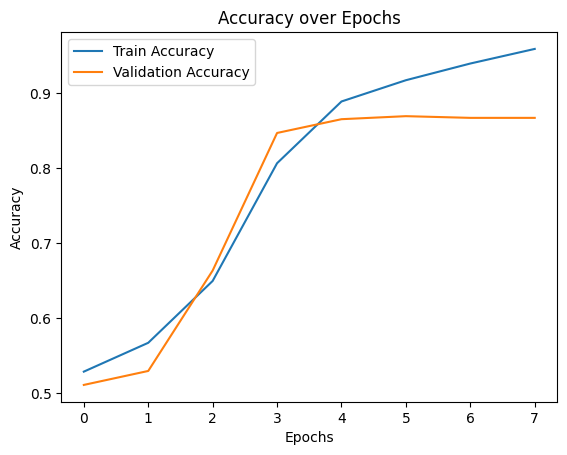

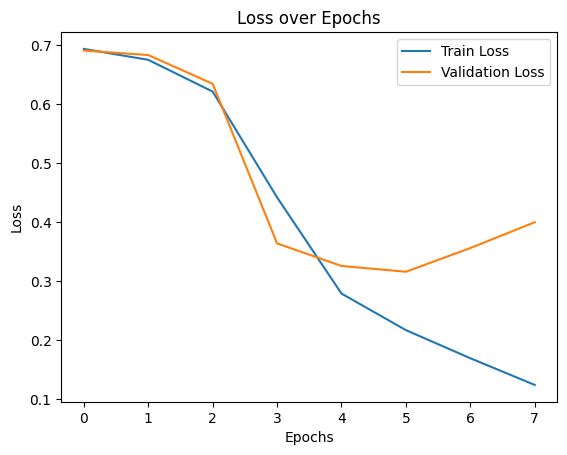

In [35]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [36]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4940
           1       0.87      0.87      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917


Confusion Matrix:
[[4301  639]
 [ 649 4328]]


In [37]:
model.save("sentiment_lstm_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [38]:
import pickle

with open("../lstm_model_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved!")


Tokenizer saved!


In [39]:
import json

config = {
    "MAX_LEN": MAX_LEN,
    "VOCAB_SIZE": VOCAB_SIZE
}

with open("../lstm_model_config.json", "w") as f:
    json.dump(config, f)

print("Configuration saved!")


Configuration saved!
